# Medical Treatment Cost Analysis & Prediction

## 1.Data Understanding


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from sklearn.metrics import accuracy_score,r2_score,mean_squared_error,classification_report,confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error



In [29]:
df = pd.read_csv("Medical.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (2000, 28)


,Customer Name,Age,Gender,Disease,State,City,Blood Group,Height (cm),Weight (kg),BMI,...,Hospital Visits/Year,Emergency Contact,Occupation,Marital Status,Income ($),Hospital Name,Doctor Assigned,Admission Date,Discharge Date,Treatment Cost ($)
0,Randall Benson,25,Female,Diabetes,Pennsylvania,Philadelphia,O+,179,96,20.00,...,0,995.364.2032,"Surveyor, rural practice",Divorced,147294,Baldwin-Erickson,Paul Kirby,12-04-2022,26-04-2022,13924
1,Michael Adams,33,Male,Cancer,Pennsylvania,Pittsburgh,B-,161,94,18.57,...,9,321-871-7351x3898,"Scientist, research (physical sciences)",Single,56292,Johnson-Gray,Taylor Cook MD,09-04-2022,20-04-2022,3043
2,Amber Collins,35,Male,Cancer,North Carolina,Raleigh,AB+,155,115,29.17,...,9,(010)587-3448,Forensic psychologist,Single,142028,Bray Ltd,Alyssa Oliver,29-05-2023,03-06-2023,10758
3,Michael Oconnor,43,Other,Arthritis,Michigan,Ann Arbor,O-,170,78,29.32,...,8,001-381-054-2814x29404,Osteopath,Single,52877,Taylor and Sons,Tyler Peterson,02-06-2024,07-06-2024,8935
4,Sean Woodward,19,Male,Depression,Texas,Austin,B+,196,89,20.17,...,6,1097157216,Associate Professor,Married,94955,Smith Group,Gregory Whitaker,19-08-2024,30-08-2024,9694


In [30]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Customer Name                 2000 non-null   object 
 1   Age                           2000 non-null   int64  
 2   Gender                        2000 non-null   object 
 3   Disease                       2000 non-null   object 
 4   State                         2000 non-null   object 
 5   City                          2000 non-null   object 
 6   Blood Group                   2000 non-null   object 
 7   Height (cm)                   2000 non-null   int64  
 8   Weight (kg)                   2000 non-null   int64  
 9   BMI                           2000 non-null   float64
 10  Smoking Status                2000 non-null   object 
 11  Alcohol Consumption           2000 non-null   object 
 12  Physical Activity (hrs/week)  2000 non-null   float64
 13  Blo

In [31]:
df.describe()   

,Age,Height (cm),Weight (kg),BMI,Physical Activity (hrs/week),Cholesterol Level,Sugar Level,Hospital Visits/Year,Income ($),Treatment Cost ($)
count,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,54.42100,175.477500,85.407500,26.722255,5.024750,199.814000,134.579500,4.999500,84913.018500,10129.471000
std,21.22442,14.767957,20.321957,4.856601,2.827435,29.654782,37.529401,3.199315,37047.464548,5625.307424
min,18.00000,150.000000,50.000000,18.510000,0.000000,150.000000,70.000000,0.000000,20021.000000,500.000000
25%,36.00000,163.000000,68.000000,22.457500,2.600000,174.000000,103.000000,2.000000,52943.750000,5150.500000
50%,54.00000,176.000000,86.000000,26.620000,5.000000,199.000000,134.000000,5.000000,85121.500000,10029.500000
75%,73.00000,188.000000,102.000000,31.092500,7.400000,226.000000,166.000000,8.000000,116482.750000,15112.500000
max,90.00000,200.000000,120.000000,34.990000,10.000000,250.000000,200.000000,10.000000,149916.000000,19999.000000


In [32]:
df.columns

Index(['Customer Name', 'Age', 'Gender', 'Disease', 'State', 'City',
       'Blood Group', 'Height (cm)', 'Weight (kg)', 'BMI', 'Smoking Status',
       'Alcohol Consumption', 'Physical Activity (hrs/week)', 'Blood Pressure',
       'Cholesterol Level', 'Sugar Level', 'Allergies', 'Medication',
       'Hospital Visits/Year', 'Emergency Contact', 'Occupation',
       'Marital Status', 'Income ($)', 'Hospital Name', 'Doctor Assigned',
       'Admission Date', 'Discharge Date', 'Treatment Cost ($)'],
      dtype='object')

In [33]:
df.isnull().sum()

Customer Name                     0
Age                               0
Gender                            0
Disease                           0
State                             0
City                              0
Blood Group                       0
Height (cm)                       0
Weight (kg)                       0
BMI                               0
Smoking Status                    0
Alcohol Consumption               0
Physical Activity (hrs/week)      0
Blood Pressure                    0
Cholesterol Level                 0
Sugar Level                       0
Allergies                       423
Medication                        0
Hospital Visits/Year              0
Emergency Contact                 0
Occupation                        0
Marital Status                    0
Income ($)                        0
Hospital Name                     0
Doctor Assigned                   0
Admission Date                    0
Discharge Date                    0
Treatment Cost ($)          

In [34]:
df.nunique()

Customer Name                   1972
Age                               73
Gender                             3
Disease                           10
State                             10
City                              30
Blood Group                        8
Height (cm)                       51
Weight (kg)                       71
BMI                             1148
Smoking Status                     2
Alcohol Consumption                2
Physical Activity (hrs/week)     101
Blood Pressure                  1128
Cholesterol Level                101
Sugar Level                      131
Allergies                          4
Medication                       833
Hospital Visits/Year              11
Emergency Contact               2000
Occupation                       596
Marital Status                     4
Income ($)                      1986
Hospital Name                   1910
Doctor Assigned                 1970
Admission Date                   912
Discharge Date                   922
T

In [35]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)


Numerical Columns: Index(['Age', 'Height (cm)', 'Weight (kg)', 'BMI',
       'Physical Activity (hrs/week)', 'Cholesterol Level', 'Sugar Level',
       'Hospital Visits/Year', 'Income ($)', 'Treatment Cost ($)'],
      dtype='object')
Categorical Columns: Index(['Customer Name', 'Gender', 'Disease', 'State', 'City', 'Blood Group',
       'Smoking Status', 'Alcohol Consumption', 'Blood Pressure', 'Allergies',
       'Medication', 'Emergency Contact', 'Occupation', 'Marital Status',
       'Hospital Name', 'Doctor Assigned', 'Admission Date', 'Discharge Date'],
      dtype='object')


## 2. Exploratory Data Analysis (EDA)

The goal of EDA is to understand:
- Patient demographics
- Disease patterns
- Cost distribution
- Correlations between medical variables

### UNIVARIATE ANALYSIS

Numerical Features

Age Distribution

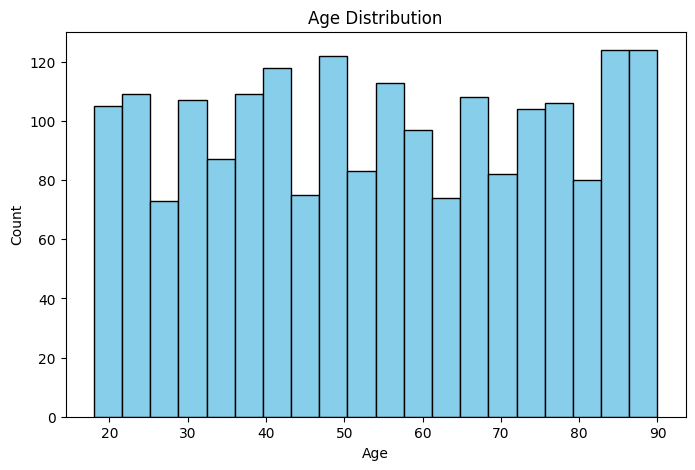

In [36]:
plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=20, color='skyblue', edgecolor='black')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


BMI Distribution

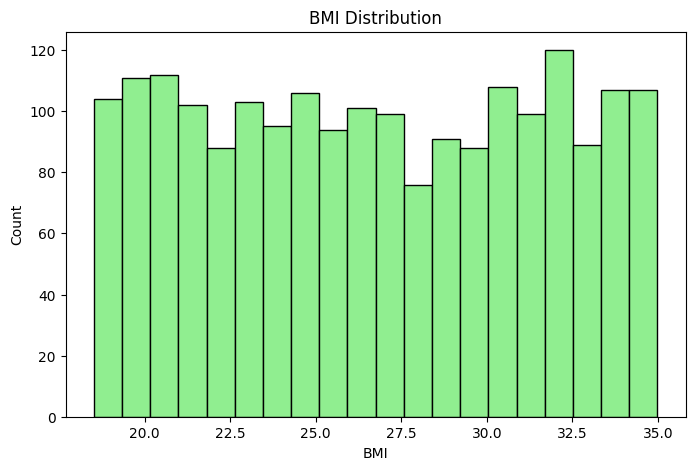

In [37]:
plt.figure(figsize=(8,5))
plt.hist(df["BMI"], bins=20, color='lightgreen', edgecolor='black')
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.show()

Treatment Cost Distribution

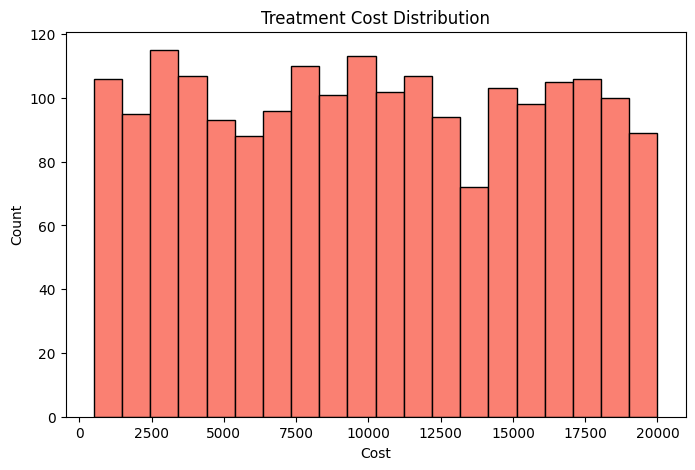

In [38]:
plt.figure(figsize=(8,5))
df.rename(columns={"Treatment Cost ($)": "Treatment Cost"}, inplace=True)
plt.hist(df["Treatment Cost"], bins=20, color='salmon', edgecolor='black')
plt.title("Treatment Cost Distribution")
plt.xlabel("Cost")
plt.ylabel("Count")
plt.show()


Disease Frequency

Disease
COVID-19         227
Cancer           216
Migraine         209
Arthritis        208
Heart Disease    201
Hypertension     190
Flu              190
Diabetes         188
Asthma           186
Depression       185
Name: count, dtype: int64


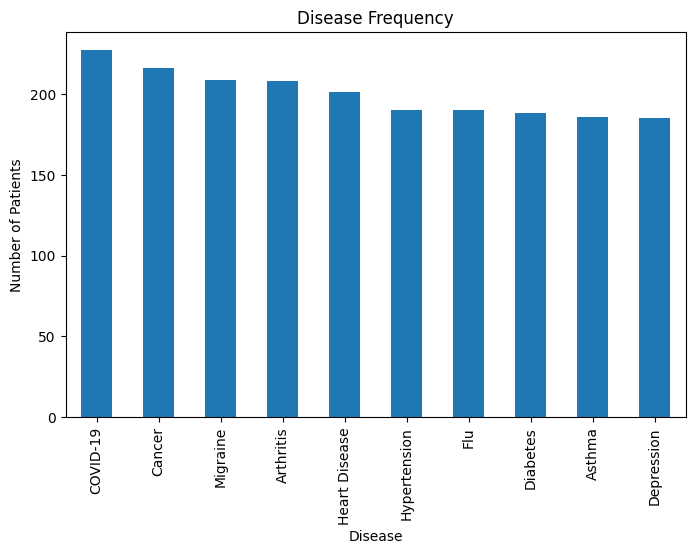

In [39]:
plt.figure(figsize=(8,5))
Disease_Count=df["Disease"].value_counts()
print(Disease_Count)
Disease_Count.plot(kind="bar")
plt.title("Disease Frequency")
plt.xlabel("Disease")
plt.ylabel("Number of Patients")
plt.show()

Gender Distribution

Gender Distribution:
Gender
Female    684
Other     667
Male      649
Name: count, dtype: int64


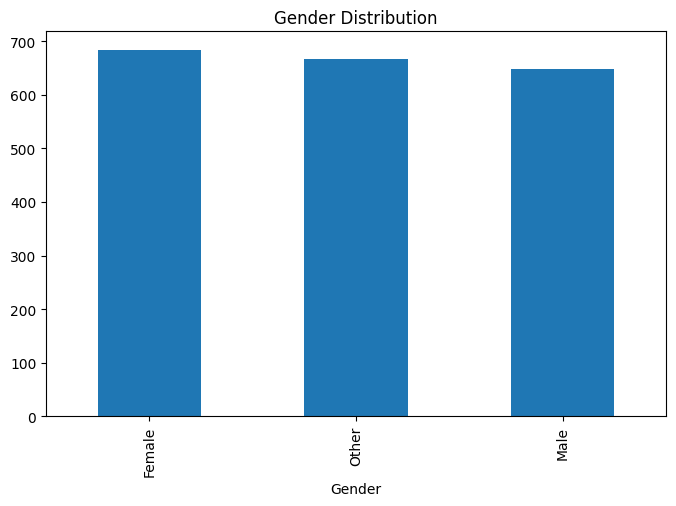

In [40]:
print("Gender Distribution:")
print(df["Gender"].value_counts())
plt.figure(figsize=(8,5))
gender_counts =df["Gender"].value_counts()
gender_counts.plot(kind="bar")
plt.title("Gender Distribution")
plt.show()


### BIVARIATE ANALYSIS 

Disease vs Treatment Cost

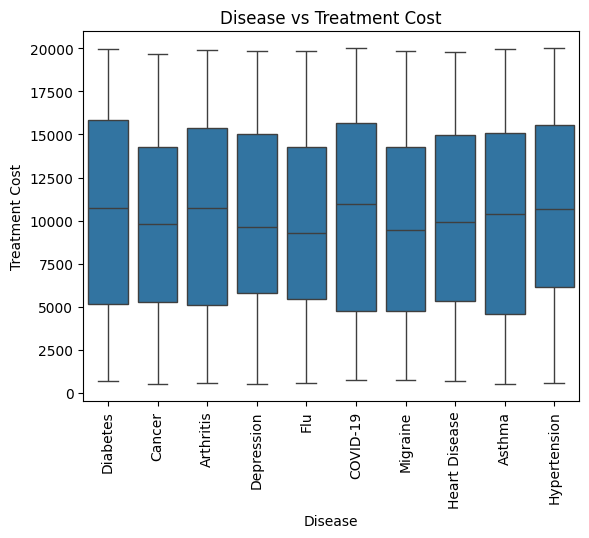

In [41]:
sns.boxplot(x="Disease", y="Treatment Cost", data=df)
plt.xticks(rotation=90)
plt.title("Disease vs Treatment Cost")
plt.show()


Age vs Treatment Cost

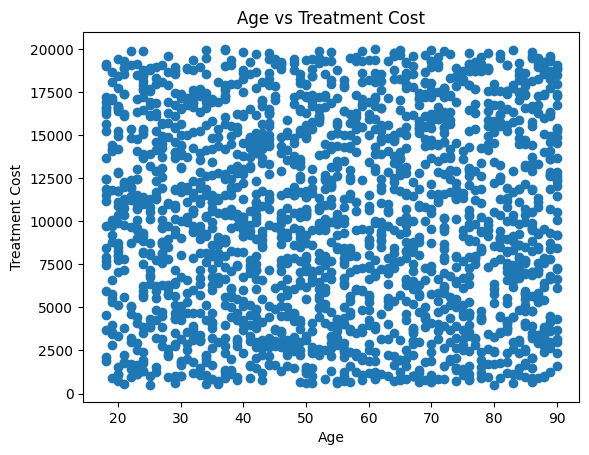

In [42]:
plt.scatter(df["Age"], df["Treatment Cost"])
plt.xlabel("Age")
plt.ylabel("Treatment Cost")
plt.title("Age vs Treatment Cost")
plt.show()


Smoking Status vs Treatment Cost

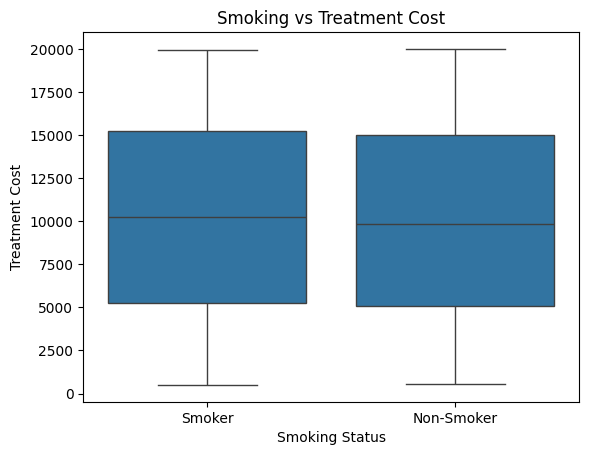

In [43]:
sns.boxplot(x="Smoking Status", y="Treatment Cost", data=df)
plt.title("Smoking vs Treatment Cost")
plt.show()

### MULTIVARIATE ANALYSIS

Correlation Heatmap

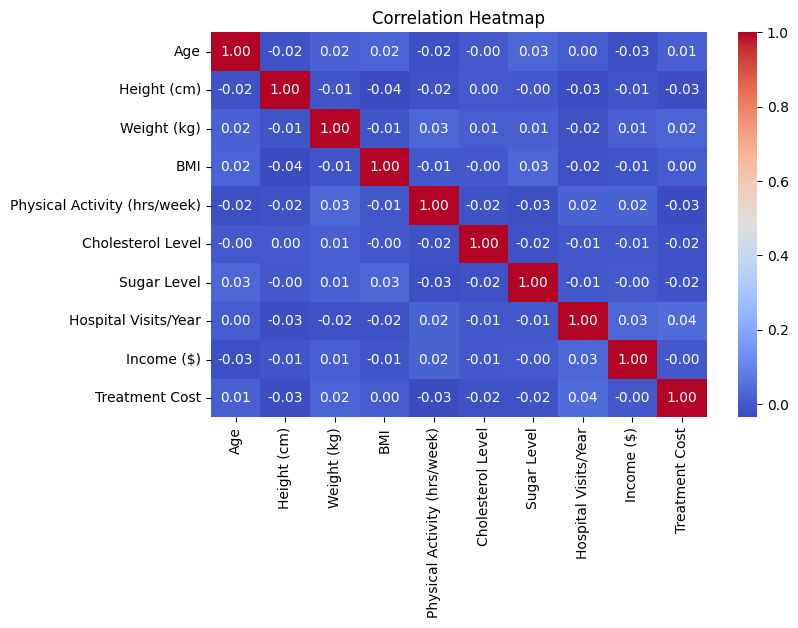

In [46]:
plt.figure(figsize=(8,5))
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


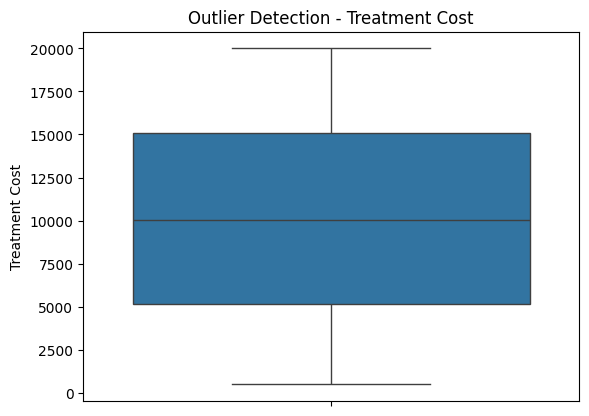

In [47]:
sns.boxplot(y=df["Treatment Cost"])
plt.title("Outlier Detection - Treatment Cost")
plt.show()


##### GROUPING

Average Treatment Cost per Disease

In [48]:
print("Average Treatment Cost per Disease:")
print(df.groupby("Disease")["Treatment Cost"].mean())


Average Treatment Cost per Disease:
Disease
Arthritis        10349.538462
Asthma           10192.193548
COVID-19         10416.837004
Cancer            9738.629630
Depression       10024.324324
Diabetes         10616.058511
Flu               9623.589474
Heart Disease    10122.865672
Hypertension     10595.210526
Migraine          9644.674641
Name: Treatment Cost, dtype: float64


Patient Count per Disease

In [49]:
print("Patient Count per Disease:")
print(df.groupby("Disease").size())


Patient Count per Disease:
Disease
Arthritis        208
Asthma           186
COVID-19         227
Cancer           216
Depression       185
Diabetes         188
Flu              190
Heart Disease    201
Hypertension     190
Migraine         209
dtype: int64


Average Cost by Gender

In [50]:
print("Average Cost by Gender:")
print(df.groupby("Gender")["Treatment Cost"].mean())


Average Cost by Gender:
Gender
Female    10256.812865
Male      10219.933744
Other      9910.862069
Name: Treatment Cost, dtype: float64


## 3. Model Building

Two machine learning models were developed:

1. Random Forest Regressor  
   - Predict treatment cost

2. Random Forest Classifier  
   - Predict disease category

### Treatment Cost Prediction using Random Forest Regressor

In [51]:
df=pd.read_csv("Medical.csv")
df.rename(columns={
    "Treatment Cost ($)":"Treatment Cost",
    "Income ($)":"Income",
    "Height (cm)":"Height",
    "Weight (kg)":"Weight",
    "Physical Activity (hrs/week)":"Physical Activity"},inplace=True)
df["Admission Date"] = pd.to_datetime(df["Admission Date"], format="%d-%m-%Y")
df["Discharge Date"] = pd.to_datetime(df["Discharge Date"], format="%d-%m-%Y")
df["Length_of_Stay"] = (df["Discharge Date"] - df["Admission Date"]).dt.days


In [52]:
df.drop(columns=["Customer Name",
                "Doctor Assigned",
                "Hospital Name",
                 "City",
                 "Admission Date",
                 "Discharge Date",
                 "Emergency Contact",
                 "Occupation",
                 "Marital Status",
                 "Gender",
                 "State",
                 "Income",
                 "Blood Group",
                 "Height",
                 "Weight",
                 "Medication",
                 "Allergies",
                 "Length_of_Stay"],inplace=True)


In [53]:
df[["BP_Systolic", "BP_Diastolic"]] = df["Blood Pressure"].str.split("/", expand=True)
df["BP_Systolic"] = df["BP_Systolic"].astype(int)
df["BP_Diastolic"] = df["BP_Diastolic"].astype(int)
df.drop(columns=["Blood Pressure"], inplace=True)


In [54]:
categorical_cols = [
    "Disease",
    "Smoking Status",
    "Alcohol Consumption",
]
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [55]:
df["Physical Activity"] = df["Physical Activity"].astype(float)


In [56]:
X = df.drop(columns=["Treatment Cost"])
y = np.log1p(df["Treatment Cost"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
                                                    
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    min_samples_leaf=5,
)

rf.fit(X_train, y_train)


,n_estimators,300
,criterion,'squared_error'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [57]:
y_pred = rf.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: -0.03345902124837363
MSE: 0.6764150071972495
RMSE: 0.822444531380232
MAE: 0.6584162287488609


In [58]:
numeric_cols = X.select_dtypes(include=["int64","float64"]).columns

corr = pd.concat([X[numeric_cols], y], axis=1).corr()["Treatment Cost"].sort_values(ascending=False)
print(corr)


Treatment Cost          1.000000
Hospital Visits/Year    0.048520
BP_Diastolic            0.018676
BP_Systolic             0.017488
BMI                     0.004507
Age                     0.004011
Cholesterol Level      -0.025765
Sugar Level            -0.026217
Physical Activity      -0.044140
Name: Treatment Cost, dtype: float64


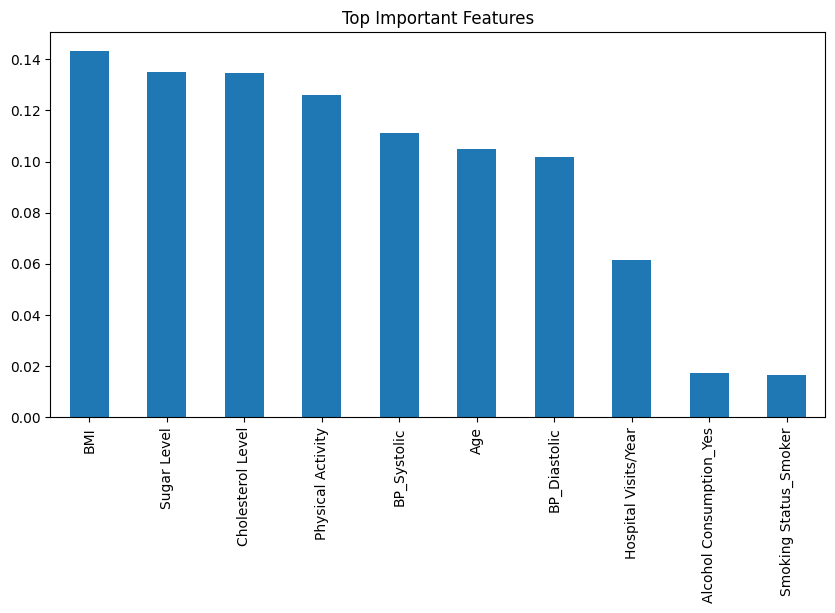

In [59]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,5))
feature_importance.head(10).plot(kind="bar")
plt.title("Top Important Features")
plt.show()

### Disease Classification using Random Forest Classifier

In [60]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
df=pd.read_csv("Medical.csv")
df.rename(columns={
    "Treatment Cost ($)":"Treatment Cost",
    "Income ($)":"Income",
    "Height (cm)":"Height",
    "Weight (kg)":"Weight",
    "Physical Activity (hrs/week)":"Physical Activity"},inplace=True)
df.drop(columns=["Customer Name",
                "Doctor Assigned",
                "Hospital Name",
                 "City",
                 "Admission Date",
                 "Discharge Date",
                 "Emergency Contact",
                 "Occupation",
                 "Marital Status",
                 "State",
                 "Income",
                 "Blood Group",
                 "Height",
                 "Weight",
                 "Medication",
                 "Allergies",],inplace=True)
df[["BP_Systolic", "BP_Diastolic"]] = df["Blood Pressure"].str.split("/", expand=True)
df["BP_Systolic"] = df["BP_Systolic"].astype(int)
df["BP_Diastolic"] = df["BP_Diastolic"].astype(int)
df.drop(columns=["Blood Pressure"], inplace=True)
categorical_cols = [
    "Gender",
    "Smoking Status",
    "Alcohol Consumption",
]
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df["Physical Activity"] = df["Physical Activity"].astype(float)


X = df.drop(columns=["Disease"])
y = df["Disease"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    random_state=42
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.1075
               precision    recall  f1-score   support

    Arthritis       0.09      0.12      0.10        42
       Asthma       0.06      0.05      0.06        37
     COVID-19       0.11      0.16      0.13        45
       Cancer       0.14      0.19      0.16        43
   Depression       0.07      0.05      0.06        37
     Diabetes       0.17      0.13      0.15        38
          Flu       0.00      0.00      0.00        38
Heart Disease       0.07      0.05      0.06        40
 Hypertension       0.14      0.13      0.14        38
     Migraine       0.17      0.17      0.17        42

     accuracy                           0.11       400
    macro avg       0.10      0.10      0.10       400
 weighted avg       0.10      0.11      0.10       400



## 4. Key Findings

- Treatment cost patterns varied across diseases and patient characteristics.
- Random Forest models helped identify important predictive features.
- Proper preprocessing significantly improved model readiness.
- Model performance depends heavily on data quality and feature relationships.

## 5. Limitations

- Dataset may not fully represent real-world healthcare complexity.
- Limited feature relationships can affect prediction performance.
- More clinical features could improve predictive accuracy.

## Conclusion

This project explored healthcare treatment cost analysis using machine learning techniques. Exploratory Data Analysis (EDA), feature engineering, and Random Forest models were applied for treatment cost prediction and disease classification. The project highlights the importance of preprocessing, feature selection, and model evaluation in healthcare analytics.